In [ ]:
import pandas as pd
import numpy as np
import os
from scipy import stats
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


In [5]:
current_path = os.getcwd()
current_path

'd:\\Powerpulse'

In [7]:
csv_file_name_path = current_path + '\\household_power_consumption.txt'
df = pd.read_csv(csv_file_name_path, delimiter=';')

C:\Users\Sivabarani M\AppData\Local\Temp\ipykernel_17404\4040761162.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_name_path, delimiter=';')


In [8]:
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.0,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.7,3.8,0.0,0.0,0.0


In [9]:
df.shape

(2075259, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [11]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df[df.isnull().any(axis=1)]

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,?,?,?,?,?,?,NaN
6840,21/12/2006,11:24:00,?,?,?,?,?,?,NaN
19724,30/12/2006,10:08:00,?,?,?,?,?,?,NaN
19725,30/12/2006,10:09:00,?,?,?,?,?,?,NaN
41832,14/1/2007,18:36:00,?,?,?,?,?,?,NaN
...,...,...,...,...,...,...,...,...,...
1990185,28/9/2010,19:09:00,?,?,?,?,?,?,NaN
1990186,28/9/2010,19:10:00,?,?,?,?,?,?,NaN
1990187,28/9/2010,19:11:00,?,?,?,?,?,?,NaN
1990188,28/9/2010,19:12:00,?,?,?,?,?,?,NaN


In [14]:
# Some value are filled with '?'. I have found how many values are filled with ?
df.where(df == '?').count()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3               0
dtype: int64

In [15]:
df.replace(to_replace='?', value=np.nan, inplace=True)

In [17]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

In [18]:
df.dropna(inplace=True)

In [19]:
df.shape

(2049280, 9)

In [20]:
df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [21]:
df['Date_time'] = df['Date'] + ' ' + df['Time']

In [22]:
df.drop(columns=['Date', 'Time'], inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    object 
 1   Global_reactive_power  object 
 2   Voltage                object 
 3   Global_intensity       object 
 4   Sub_metering_1         object 
 5   Sub_metering_2         object 
 6   Sub_metering_3         float64
 7   Date_time              object 
dtypes: float64(1), object(7)
memory usage: 140.7+ MB


In [24]:
df['Date_time'] = pd.to_datetime(df['Date_time'])

C:\Users\Sivabarani M\AppData\Local\Temp\ipykernel_17404\4141771076.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_time'] = pd.to_datetime(df['Date_time'])


In [26]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Date_time
0,4.216,0.418,234.840,18.400,0.000,1.000,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.630,23.000,0.000,1.000,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.290,23.000,0.000,2.000,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.740,23.000,0.000,1.000,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.680,15.800,0.000,1.000,17.0,2006-12-16 17:28:00


In [27]:
for i in df.select_dtypes(include=['object']).columns:
  df[i] = pd.to_numeric(df[i])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2049280 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Date_time              datetime64[ns]
dtypes: datetime64[ns](1), float64(7)
memory usage: 140.7 MB


In [29]:
df['Date_time'].nunique()

2049280

In [30]:
def get_time_of_day(date):
    if date.hour < 6:
        return 'Early Morning'
    elif date.hour < 12:
        return 'Morning'
    elif date.hour < 18:
        return 'Afternoon'
    elif date.hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_day'] = df['Date_time'].apply(get_time_of_day)

In [31]:
# Get Day Type
def get_day_type(date):
    if date.weekday() in [5, 6]:
        return 'Weekend'
    else:
        return 'Weekday'

df['Day_type'] = df['Date_time'].apply(get_day_type)

In [32]:
# Get Season
def get_season_exact(date):
    if date.month in [12, 1, 2]:
        return 'Winter'
    elif date.month in [3, 4, 5]:
        return 'Spring'
    elif date.month in [6, 7, 8]:
        return 'Summer'
    elif date.month in [9, 10, 11]:
        return 'Fall'

df['Season'] = df['Date_time'].apply(get_season_exact)

In [33]:
df['Day'] =  df['Date_time'].dt.day
df['Month'] =  df['Date_time'].dt.month
df['Year'] =  df['Date_time'].dt.year
df['Hour'] =  df['Date_time'].dt.hour
df['Minute'] =  df['Date_time'].dt.minute
df['Second'] =  df['Date_time'].dt.second

In [ ]:
# Rolling Average (example: 1-hour = 60 minutes rolling window)
df["Rolling_avg_power"] = df["Global_active_power"].rolling(window=60, min_periods=1).mean()

# Daily Average Power Consumption
df["Daily_avg_power"] = df.groupby([df["Year"], df["Month"], df["Day"]])["Global_active_power"].transform("mean")

In [46]:
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Time_of_day,Day_type,Season,Day,Month,Year,Hour,Minute,Second,Rolling_avg_power,Daily_avg_power
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,24,0,4.216000,3.053475
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Afternoon,Weekend,Winter,16,12,2006,17,25,0,4.788000,3.053475
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,26,0,4.983333,3.053475
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,27,0,5.084500,3.053475
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,28,0,4.800800,3.053475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2075254,0.946,0.000,240.43,4.0,0.0,0.0,0.0,Evening,Weekday,Fall,26,11,2010,20,58,0,1.173367,1.178230
2075255,0.944,0.000,240.00,4.0,0.0,0.0,0.0,Evening,Weekday,Fall,26,11,2010,20,59,0,1.163700,1.178230
2075256,0.938,0.000,239.82,3.8,0.0,0.0,0.0,Night,Weekday,Fall,26,11,2010,21,0,0,1.155067,1.178230
2075257,0.934,0.000,239.70,3.8,0.0,0.0,0.0,Night,Weekday,Fall,26,11,2010,21,1,0,1.144733,1.178230


In [47]:
df.to_csv("cleaned_data.csv", index=False)

In [2]:
cleaned_df = pd.read_csv("cleaned_data.csv")

In [3]:
cleaned_df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Time_of_day', 'Day_type', 'Season', 'Day', 'Month',
       'Year', 'Hour', 'Minute', 'Second', 'Rolling_avg_power',
       'Daily_avg_power'],
      dtype='object')

In [6]:
cleaned_df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Time_of_day,Day_type,Season,Day,Month,Year,Hour,Minute,Second,Rolling_avg_power,Daily_avg_power
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,24,0,4.216000,3.053475
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,Afternoon,Weekend,Winter,16,12,2006,17,25,0,4.788000,3.053475
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,26,0,4.983333,3.053475
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,27,0,5.084500,3.053475
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,Afternoon,Weekend,Winter,16,12,2006,17,28,0,4.800800,3.053475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049275,0.946,0.000,240.43,4.0,0.0,0.0,0.0,Evening,Weekday,Fall,26,11,2010,20,58,0,1.173367,1.178230
2049276,0.944,0.000,240.00,4.0,0.0,0.0,0.0,Evening,Weekday,Fall,26,11,2010,20,59,0,1.163700,1.178230
2049277,0.938,0.000,239.82,3.8,0.0,0.0,0.0,Night,Weekday,Fall,26,11,2010,21,0,0,1.155067,1.178230
2049278,0.934,0.000,239.70,3.8,0.0,0.0,0.0,Night,Weekday,Fall,26,11,2010,21,1,0,1.144733,1.178230


In [7]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   Time_of_day            object 
 8   Day_type               object 
 9   Season                 object 
 10  Day                    int64  
 11  Month                  int64  
 12  Year                   int64  
 13  Hour                   int64  
 14  Minute                 int64  
 15  Second                 int64  
 16  Rolling_avg_power      float64
 17  Daily_avg_power        float64
dtypes: float64(9), int64(6), object(3)
memory usage: 281.4+ MB


In [3]:
# Encoding
from sklearn.preprocessing import LabelEncoder

for i in cleaned_df.select_dtypes(include=['object']).columns:
  le = LabelEncoder()
  cleaned_df[i] = le.fit_transform(cleaned_df[i])

In [8]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2049280 entries, 0 to 2049279
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
 7   Time_of_day            object 
 8   Day_type               object 
 9   Season                 object 
 10  Day                    int64  
 11  Month                  int64  
 12  Year                   int64  
 13  Hour                   int64  
 14  Minute                 int64  
 15  Second                 int64  
 16  Rolling_avg_power      float64
 17  Daily_avg_power        float64
dtypes: float64(9), int64(6), object(3)
memory usage: 281.4+ MB


In [11]:
cleaned_df.corr()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Time_of_day,Day_type,Season,Day,Month,Year,Hour,Minute,Second,Rolling_avg_power,Daily_avg_power
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555,0.188239,0.084633,0.046083,0.002052,-0.032654,-0.034328,0.281602,0.002422,NaN,0.773636,0.394716
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617,-0.014334,0.088927,-0.007252,0.000674,0.027211,0.047018,0.127892,0.000186,NaN,0.168506,0.011895
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172,-0.147253,-0.021743,0.120535,0.023525,-0.015191,0.254623,-0.176050,0.009733,NaN,-0.308107,0.074252
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543,0.185534,0.086542,0.044296,0.001447,-0.031417,-0.038621,0.281972,0.002354,NaN,0.768905,0.388434
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571,0.042418,0.065175,-0.000331,-0.005312,-0.007513,-0.012557,0.108491,-0.000543,NaN,0.253235,0.097703
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872,-0.031284,0.042660,-0.000746,0.003657,-0.009763,-0.035939,0.087210,-0.002127,NaN,0.271264,0.120049
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000,0.136678,0.018087,0.014818,-0.000799,-0.030791,0.062396,0.113873,-0.000419,NaN,0.572762,0.221864
Time_of_day,0.188239,-0.014334,-0.147253,0.185534,0.042418,-0.031284,0.136678,1.000000,0.000210,0.000464,-0.000013,-0.000087,-0.000301,0.273132,0.000035,NaN,0.232489,0.001186
Day_type,0.084633,0.088927,-0.021743,0.086542,0.065175,0.042660,0.018087,0.000210,1.000000,0.003559,0.000885,0.002181,-0.004834,0.000082,-0.000024,NaN,0.099670,0.214414
Season,0.046083,-0.007252,0.120535,0.044296,-0.000331,-0.000746,0.014818,0.000464,0.003559,1.000000,0.020109,-0.406854,-0.068761,0.000219,0.000028,NaN,0.054259,0.116750


In [4]:
# I have found that the columns 'Second', 'Minute', 'Day', and 'Day_type' have a low impact on Global_active_power. 
# The Second column is especially uninformative, as all its values are 0, so it will be removed. 
# The remaining columns will be considered for removal after hypothesis testing
cleaned_df.drop(columns=['Second'], inplace=True)

In [6]:
cleaned_df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3', 'Time_of_day', 'Day_type', 'Season', 'Day', 'Month',
       'Year', 'Hour', 'Minute', 'Rolling_avg_power', 'Daily_avg_power'],
      dtype='object')

In [5]:
for i in cleaned_df.columns:
  print(i, cleaned_df[i].nunique())

Global_active_power 4186
Global_reactive_power 532
Voltage 2837
Global_intensity 221
Sub_metering_1 88
Sub_metering_2 81
Sub_metering_3 32
Time_of_day 5
Day_type 2
Season 4
Day 31
Month 12
Year 5
Hour 24
Minute 60
Rolling_avg_power 207945
Daily_avg_power 1433


In [ ]:
continuous_variable = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 
                       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

categorical_variable = ['Time_of_day', 'Day_type', 'Season', 'Day', 'Minute', 'Month', 'Year', 'Hour']

In [9]:
def continous_vs_continous(d1,d2):
  T=0
  F=0
  for i in range(31):
    sample1 = d1.sample(frac=0.03)
    sample2 = d2.sample(frac=0.03)
    t_test,p_value = stats.ttest_ind(sample1,sample2)
    if p_value < 0.07:
      F = F+1
    else:
      T = T+1
  if F > T:
    return False
  else:
    return True

def category_vs_category(d1,d2):
  return True if stats.chi2_contingency(pd.crosstab(d1,d2))[1] < 0.07 else False

def continous_vs_category(d1,d2):
  group = cleaned_df[d2].unique()
  data = {}
  for i in group:
    data[i] = cleaned_df[cleaned_df[d2] == i][d1]
  f_value,p_value = stats.f_oneway(*[i for i in data.values()])
  return True if p_value > 0.07 else False

df_test = {}
for i in cleaned_df.columns:
  df_test[i] = {}
  for j in cleaned_df.columns:
    if (i in continuous_variable) and (j in continuous_variable):
      result = continous_vs_continous(cleaned_df[i],cleaned_df[j])
    elif (i in continuous_variable) and (j in categorical_variable):
      result = continous_vs_category(i,j)
    elif (i in categorical_variable) and (j in categorical_variable):
      result = category_vs_category(cleaned_df[i],cleaned_df[j])
    elif (i in categorical_variable) and (j in continuous_variable):
      result = continous_vs_category(j,i)
    if result:
      df_test[i][j] = 1
    else:
      df_test[i][j] = 0


testing_result = pd.DataFrame(df_test)

In [11]:
fig = px.imshow(testing_result, text_auto=True, aspect="auto")
fig.show()

In [12]:
# Based on the statistical relationship tests with the target variable (Global_active_power), 
# the features Day_type, Season, Day, Month, Year, Hour, and Time_of_day showed no significant correlation.
# Therefore, these columns were removed to reduce noise and simplify the model.
cleaned_df.drop(columns=['Day_type', 'Season', 'Day', 'Month', "Year", 'Hour', 'Time_of_day'], inplace=True)

Global_active_power
---------------------
Skew = 1.7862333920915971, Kurtosis = 4.218685087072211



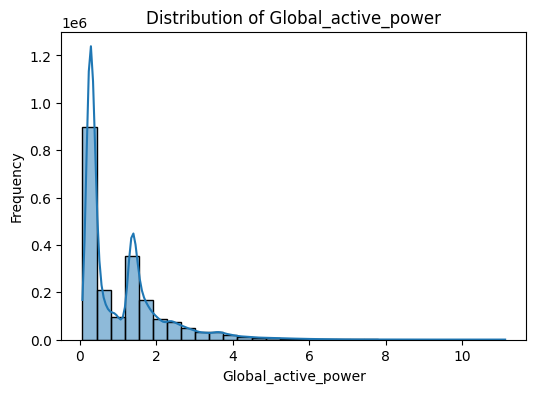

Global_reactive_power
---------------------
Skew = 1.2619141974704133, Kurtosis = 2.6056327677496096



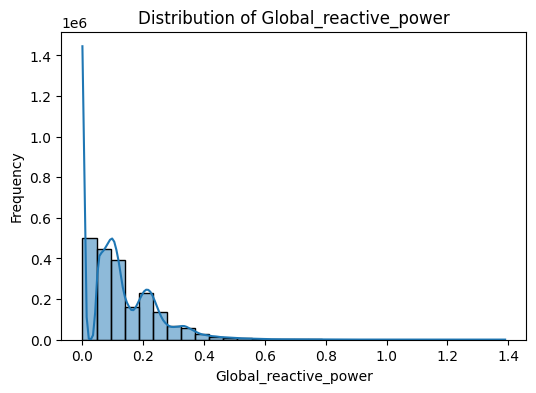

Voltage
---------------------
Skew = -0.32666497568777614, Kurtosis = 0.7247070166090532



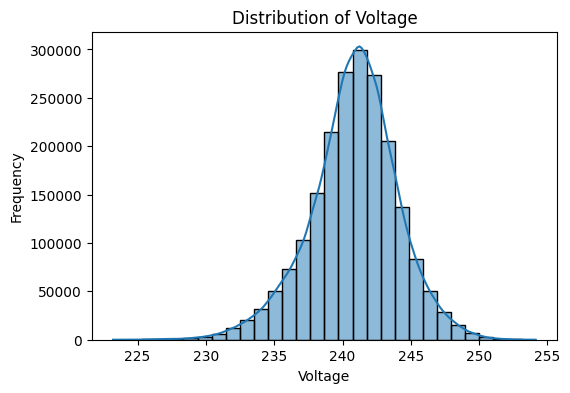

Global_intensity
---------------------
Skew = 1.8490999040716374, Kurtosis = 4.601242858337602



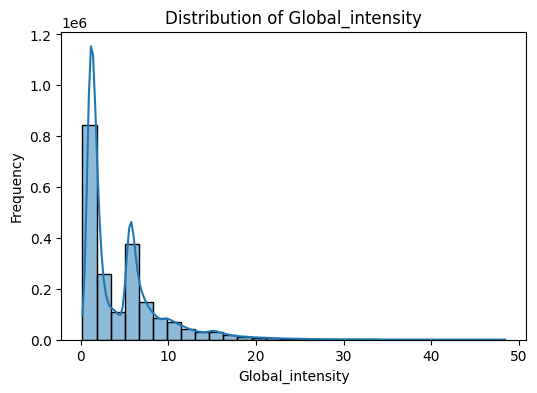

Sub_metering_1
---------------------
Skew = 5.944541281563975, Kurtosis = 35.64299268171928



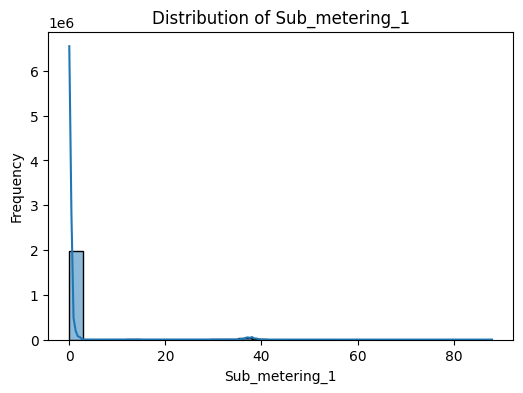

Sub_metering_2
---------------------
Skew = 7.090553230343405, Kurtosis = 57.907343604312906



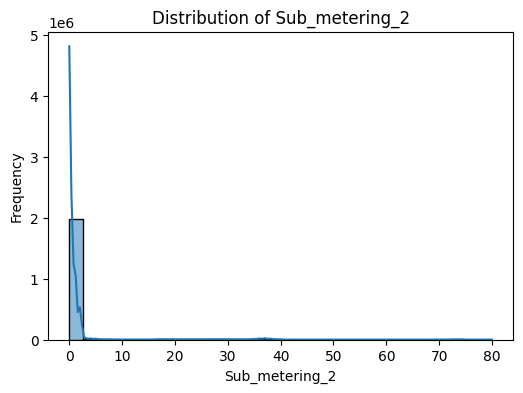

Sub_metering_3
---------------------
Skew = 0.7246883225039504, Kurtosis = -1.2821975312784248



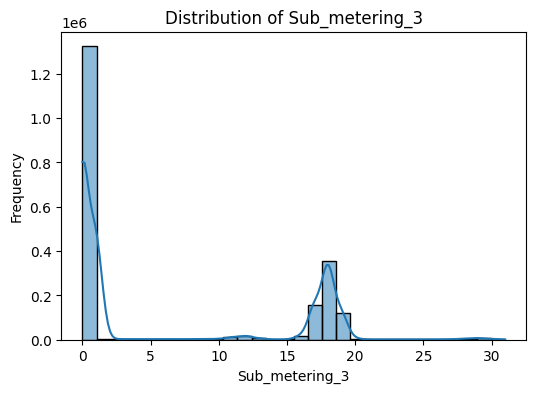

Minute
---------------------
Skew = -5.0272521329699864e-05, Kurtosis = -1.2006517305741433



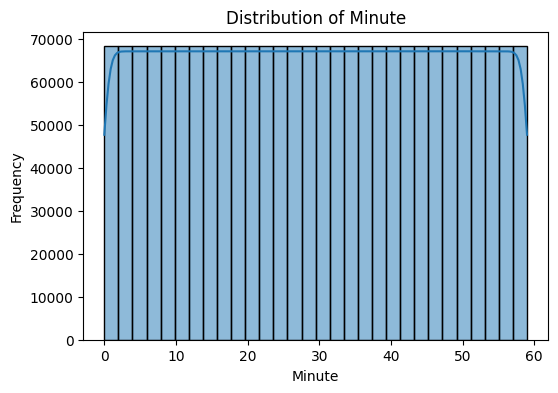

Rolling_avg_power
---------------------
Skew = 1.293448171393767, Kurtosis = 1.7592233210461323



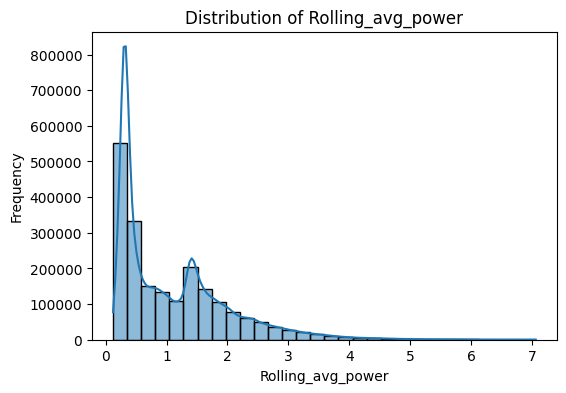

Daily_avg_power
---------------------
Skew = 0.578439555159917, Kurtosis = 1.296339379045932



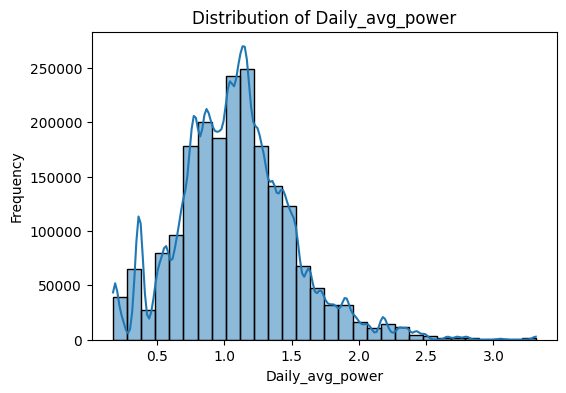

In [ ]:
for i in cleaned_df.columns:
    print(i)
    print('---------------------')
    print(f'Skew = {cleaned_df[i].skew()}, Kurtosis = {cleaned_df[i].kurtosis()}')
    print()

    # Plot distribution
    plt.figure(figsize=(6,4))
    sns.histplot(cleaned_df[i], kde=True, bins=30)   # distplot is deprecated, use histplot
    plt.title(f'Distribution of {i}')
    plt.xlabel(i)
    plt.ylabel('Frequency')
    plt.show()


In [53]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [21]:
for i in cleaned_df.columns:
  print(i)
  print('---------------------')
  print(f'skew = {cleaned_df[i].skew()}, Kurtosis = {cleaned_df[i].kurtosis()}')
  print()

Global_active_power
---------------------
skew = 1.7862333920915971, Kurtosis = 4.218685087072211

Global_reactive_power
---------------------
skew = 1.2619141974704133, Kurtosis = 2.6056327677496096

Voltage
---------------------
skew = -0.32666497568777614, Kurtosis = 0.7247070166090532

Global_intensity
---------------------
skew = 1.8490999040716374, Kurtosis = 4.601242858337602

Sub_metering_1
---------------------
skew = 5.944541281563975, Kurtosis = 35.64299268171928

Sub_metering_2
---------------------
skew = 7.090553230343405, Kurtosis = 57.907343604312906

Sub_metering_3
---------------------
skew = 0.7246883225039504, Kurtosis = -1.2821975312784248

Minute
---------------------
skew = -5.0272521329699864e-05, Kurtosis = -1.2006517305741433

Rolling_avg_power
---------------------
skew = 1.293448171393767, Kurtosis = 1.7592233210461323

Daily_avg_power
---------------------
skew = 0.578439555159917, Kurtosis = 1.296339379045932



In [14]:
transform_column = ['Global_active_power', 'Global_reactive_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Rolling_avg_power']

In [15]:
from scipy import stats

for i in transform_column:
    df = cleaned_df
    for l in [0.5,-0.5,1,-1,2,-2]:
        print(l)
        print(i," Skew = ", pd.DataFrame(stats.boxcox(df[i], lmbda=l)).skew().values, "kurtosis=", pd.DataFrame(stats.boxcox(df[i], lmbda=l)).kurtosis().values)
    print('-----------------------------------------------')

0.5
Global_active_power  Skew =  [0.80516216] kurtosis= [0.01303558]
-0.5
Global_active_power  Skew =  [-0.5692809] kurtosis= [-0.25805978]
1
Global_active_power  Skew =  [1.78623339] kurtosis= [4.21868509]
-1
Global_active_power  Skew =  [-1.63995712] kurtosis= [4.38800307]
2
Global_active_power  Skew =  [4.94256661] kurtosis= [38.02200695]
-2
Global_active_power  Skew =  [-5.31341529] kurtosis= [38.7021896]
-----------------------------------------------
0.5
Global_reactive_power  Skew =  [-0.22842433] kurtosis= [-0.70912938]
-0.5
Global_reactive_power  Skew =  [nan] kurtosis= [nan]
1
Global_reactive_power  Skew =  [1.2619142] kurtosis= [2.60563277]
-1
Global_reactive_power  Skew =  [nan] kurtosis= [nan]
2
Global_reactive_power  Skew =  [5.15759946] kurtosis= [52.95622496]
-2
Global_reactive_power  Skew =  [nan] kurtosis= [nan]
-----------------------------------------------
0.5
Global_intensity  Skew =  [0.8243686] kurtosis= [0.14788557]
-0.5
Global_intensity  Skew =  [-1.07552702] 

In [ ]:
def check_skew_kurtosis(df, columns):
    stats = {}
    for col in columns:
        stats[col] = {
            "skew": skew(df[col].dropna()),
            "kurtosis": kurtosis(df[col].dropna())
        }
    return pd.DataFrame(stats).T

def transform_features(df, columns):
    df_transformed = df.copy()
    pt = PowerTransformer(method='yeo-johnson')   
    df_transformed[columns] = pt.fit_transform(df[columns])
    return df_transformed

def scale_features(df, columns):
    df_scaled = df.copy()
    scaler = RobustScaler()   
    df_scaled[columns] = scaler.fit_transform(df[columns])
    return df_scaled

def process_data(df, columns):
    print("Before:")
    print(check_skew_kurtosis(df, columns))

    # 1. Transform
    df_transformed = transform_features(df, columns)

    # 2. Scale
    df_scaled = scale_features(df_transformed, columns)

    print("\nAfter Transformation + Scaling:")
    print(check_skew_kurtosis(df_scaled, columns))

    return df_scaled

# Example usage:
num_cols = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Rolling_avg_power', 'Daily_avg_power'
]

df_processed = process_data(cleaned_df, num_cols)


Before:
                           skew   kurtosis
Global_active_power    1.786232   4.218672
Global_reactive_power  1.261913   2.605623
Voltage               -0.326665   0.724702
Global_intensity       1.849099   4.601229
Sub_metering_1         5.944537  35.642903
Sub_metering_2         7.090548  57.907199
Sub_metering_3         0.724688  -1.282197
Rolling_avg_power      1.293447   1.759216
Daily_avg_power        0.578439   1.296333

After Transformation + Scaling:
                           skew  kurtosis
Global_active_power    0.208682 -1.380821
Global_reactive_power  0.104250 -0.897799
Voltage                0.018137  0.549247
Global_intensity       0.095410 -1.208860
Sub_metering_1         3.034689  7.209739
Sub_metering_2         0.923924 -1.076085
Sub_metering_3         0.341574 -1.620429
Rolling_avg_power      0.157347 -1.364456
Daily_avg_power        0.008509  0.504598


In [18]:
# Outliers were not removed in this dataset because high power consumption values 
# represent valid real-world events (e.g., family visits, seasonal changes, or 
# increased appliance usage). These are not data errors but genuine usage patterns, 
# and removing them would cause a loss of important behavioral information. 
# Instead of dropping, we apply transformations and robust scaling to reduce skew 
# and kurtosis while preserving all meaningful variations in energy consumption.


In [20]:
df_processed.to_csv("processed_data.csv", index=False)

In [4]:
df_processed = pd.read_csv('processed_data.csv')
df_processed

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Minute,Rolling_avg_power,Daily_avg_power
0,1.159914,1.326157,-1.456048,1.199071,0.0,1.000000,0.636552,24,1.067542,2.997690
1,1.250388,1.364754,-1.713178,1.308043,0.0,1.000000,0.626527,25,1.127493,2.997690
2,1.251291,1.481610,-1.783854,1.308043,0.0,1.168436,0.636552,26,1.145484,2.997690
3,1.252191,1.488382,-1.690166,1.308043,0.0,1.000000,0.636552,27,1.154373,2.997690
4,1.100376,1.530389,-1.272296,1.120870,0.0,1.000000,0.636552,28,1.128707,2.997690
...,...,...,...,...,...,...,...,...,...,...
2049275,0.299043,-0.925245,-0.147759,0.289529,0.0,0.000000,-0.363448,58,0.270494,0.189187
2049276,0.297614,-0.925245,-0.255787,0.289529,0.0,0.000000,-0.363448,59,0.264652,0.189187
2049277,0.293309,-0.925245,-0.300628,0.255253,0.0,0.000000,-0.363448,0,0.259393,0.189187
2049278,0.290425,-0.925245,-0.330398,0.255253,0.0,0.000000,-0.363448,1,0.253046,0.189187


In [5]:
X = df_processed.drop("Global_active_power", axis=1)
y = df_processed["Global_active_power"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [4]:
# Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred_lr = linear_reg.predict(X_test)

print("Linear Regression:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print('------------------------------------------------')

Linear Regression:
RMSE: 0.049107122814297216
R2: 0.9925418535525774
MAE: 0.035139492697744364
------------------------------------------------


In [5]:
# Decision Tree
decision_tree_reg = DecisionTreeRegressor()
decision_tree_reg.fit(X_train, y_train)
y_pred_decision_tree = decision_tree_reg.predict(X_test)

print("Decision Tree:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_decision_tree)))
print("R2:", r2_score(y_test, y_pred_decision_tree))
print("MAE:", mean_absolute_error(y_test, y_pred_decision_tree))
print('------------------------------------------------')


Decision Tree:
RMSE: 0.023664478655399092
R2: 0.9982680481662719
MAE: 0.011174531564105987
------------------------------------------------


In [6]:
# Gradient Boosting
gb_reg = GradientBoostingRegressor()
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

print("Gradient Boost:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print('------------------------------------------------')

Gradient Boost:
RMSE: 0.026578513683645846
R2: 0.9978152421457879
MAE: 0.017613624119702503
------------------------------------------------


In [5]:
# Random Forest
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("Random Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print('------------------------------------------------')

Random Forest:
RMSE: 0.0171649374337019
R2: 0.9990896313639942
MAE: 0.008963999842010182
------------------------------------------------


In [6]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_reg = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',          
    solver='adam',              
    max_iter=1000,              
    random_state=42
)

nn_reg.fit(X_train_scaled, y_train)
y_pred_nn = nn_reg.predict(X_test_scaled)

print("Neural Network (MLP):")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_nn)))
print("R2:", r2_score(y_test, y_pred_nn))
print("MAE:", mean_absolute_error(y_test, y_pred_nn))
print('------------------------------------------------')


Neural Network (MLP):
RMSE: 0.024618832391249016
R2: 0.9981275878867683
MAE: 0.01605857534627267
------------------------------------------------


In [ ]:
# After training and evaluating multiple regression models including Linear Regression, Decision Tree, Gradient Boosting, and Neural Network, 
# the Random Forest model was selected as the final model because it achieved the lowest RMSE (0.01716) and MAE (0.00896), and the highest R² (0.99909). 
# This indicates that Random Forest provides the most accurate and reliable predictions for household power consumption in this dataset.

In [7]:
# Random Forest
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("Random Forest:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print('------------------------------------------------')

Random Forest:
RMSE: 0.017141647448241617
R2: 0.999092238715626
MAE: 0.009000647529339354
------------------------------------------------


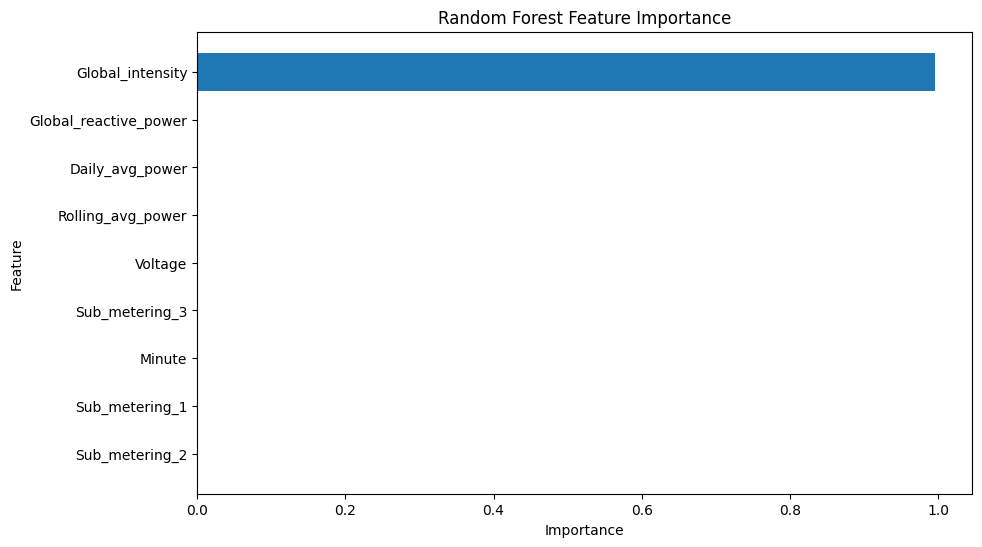

In [8]:
feature_importances = rf_reg.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


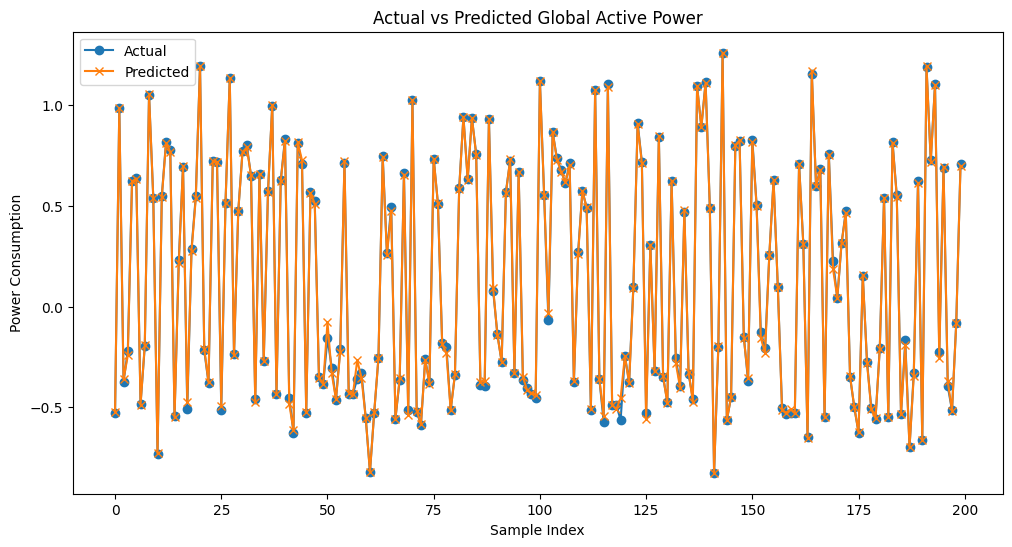

In [9]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Actual', marker='o')
plt.plot(y_pred_rf[:200], label='Predicted', marker='x')
plt.title('Actual vs Predicted Global Active Power')
plt.xlabel('Sample Index')
plt.ylabel('Power Consumption')
plt.legend()
plt.show()


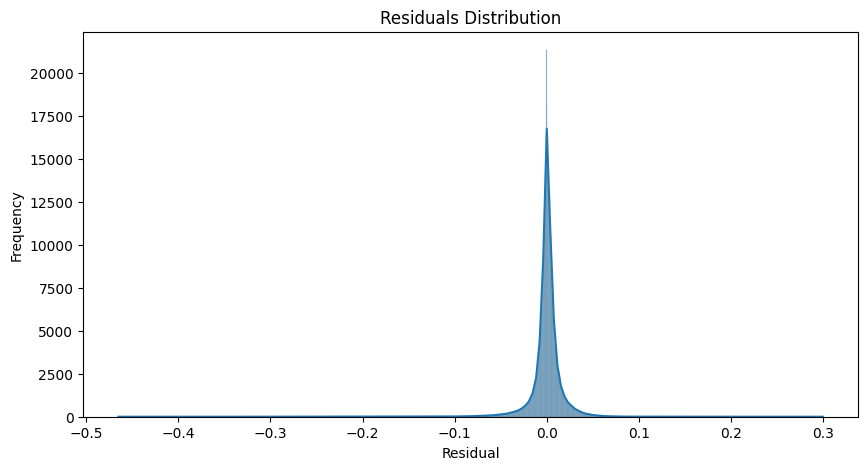

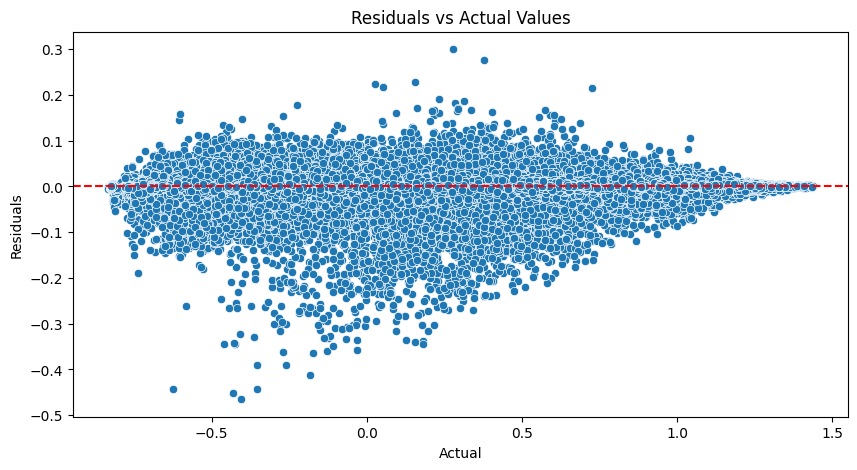

In [10]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

# Residual scatter
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Actual Values')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.show()


In [11]:
metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²'],
    'Random Forest': [np.sqrt(mean_squared_error(y_test, y_pred_rf)), mean_absolute_error(y_test, y_pred_rf), r2_score(y_test, y_pred_rf)]
})
print(metrics_df)

  Metric  Random Forest
0   RMSE       0.017142
1    MAE       0.009001
2     R²       0.999092
